# Telecom X - Parte 2: Prevendo Churn

## Contexto
Apos a etapa de analise exploratoria, este caderno apresenta a fase de Machine Learning para prever evasao de clientes.

## Objetivo
Construir e avaliar modelos de classificacao para estimar a chance de churn e transformar resultados tecnicos em recomendacoes estrategicas para retencao.

## Plano do caderno
1. Carregar base tratada em CSV
2. Preparar dados para modelagem
3. Analisar correlacao e relacoes com a evasao
4. Treinar dois modelos (Regressao Logistica e Random Forest)
5. Avaliar metricas e overfitting/underfitting
6. Interpretar variaveis mais relevantes
7. Concluir com foco em estrategia de negocio

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
pd.set_option('display.max_columns', None)

In [2]:
csv_path = Path('TelecomX_tratado.csv')
if not csv_path.exists():
    raise FileNotFoundError('Arquivo TelecomX_tratado.csv nao encontrado. Rode a Parte 1 ou gere o CSV tratado antes.')

df = pd.read_csv(csv_path)
print(f'Base carregada: {df.shape[0]} linhas x {df.shape[1]} colunas')
display(df.head(3))
display(df.dtypes.to_frame('tipo_dado'))

Base carregada: 7043 linhas x 22 colunas


,IdCliente,Evasao,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefonico,Multiplas_Linhas,Servico_Internet,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Gasto_Mensal,Gasto_Total,Contas_Diarias
0,0002-ORFBO,Nao,Feminino,0,Sim,Sim,9,Sim,Nao,DSL,Nao,Sim,Nao,Sim,Sim,Nao,Um_ano,Sim,Cheque_enviado,65.6,593.30,2.186667
1,0003-MKNFE,Nao,Masculino,0,Nao,Nao,9,Sim,Sim,DSL,Nao,Nao,Nao,Nao,Nao,Sim,Mensal,Nao,Cheque_enviado,59.9,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Nao,Nao,4,Sim,Nao,Fibra_optica,Nao,Nao,Sim,Nao,Nao,Nao,Mensal,Sim,Cheque_eletronico,73.9,280.85,2.463333


,tipo_dado
IdCliente,str
Evasao,str
Genero,str
Idoso,int64
Parceiro,str
Dependentes,str
Meses_Contrato,int64
Servico_Telefonico,str
Multiplas_Linhas,str
Servico_Internet,str


## Preparacao para modelagem
- Remocao de coluna identificadora (IdCliente)
- Definicao de alvo (Evasao)
- One-Hot Encoding para variaveis categoricas
- Padronizacao apenas no modelo sensivel a escala (Regressao Logistica)

In [3]:
df_model = df.copy()

if 'IdCliente' in df_model.columns:
    df_model = df_model.drop(columns=['IdCliente'])

df_model['Evasao_bin'] = df_model['Evasao'].map({'Sim': 1, 'Nao': 0})
if df_model['Evasao_bin'].isna().any():
    raise ValueError('A coluna Evasao possui valores fora do esperado: Sim/Nao.')

X = df_model.drop(columns=['Evasao', 'Evasao_bin'])
y = df_model['Evasao_bin']

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Features numericas: {len(num_features)} | Features categoricas: {len(cat_features)}')
print('Exemplo de features categoricas:', cat_features[:6])

Features numericas: 5 | Features categoricas: 15
Exemplo de features categoricas: ['Genero', 'Parceiro', 'Dependentes', 'Servico_Telefonico', 'Multiplas_Linhas', 'Servico_Internet']


,Quantidade,Percentual (%)
Evasao_bin,,
Evadido,1869,26.54
Permaneceu,5174,73.46


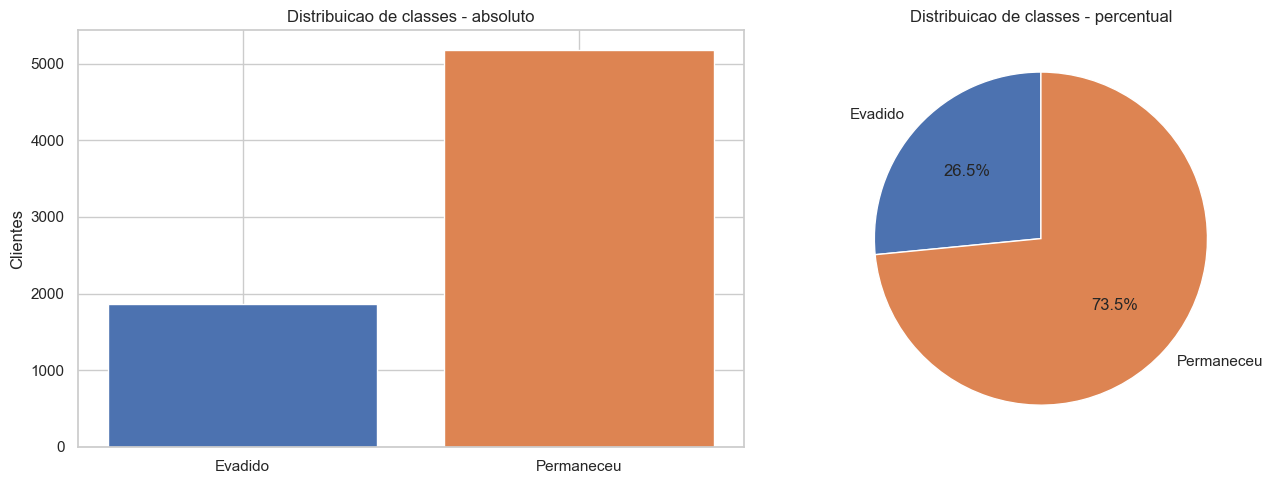

Observacao: o desbalanceamento e moderado. Neste baseline, usamos stratify no split e metricas alem da acuracia.


In [4]:
classe_pct = y.value_counts(normalize=True).mul(100).rename(index={0: 'Permaneceu', 1: 'Evadido'}).sort_index()
classe_abs = y.value_counts().rename(index={0: 'Permaneceu', 1: 'Evadido'}).sort_index()

balanceamento = pd.DataFrame({'Quantidade': classe_abs, 'Percentual (%)': classe_pct.round(2)})
display(balanceamento)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(balanceamento.index, balanceamento['Quantidade'], color=['#4c72b0', '#dd8452'])
ax[0].set_title('Distribuicao de classes - absoluto')
ax[0].set_ylabel('Clientes')

ax[1].pie(balanceamento['Percentual (%)'], labels=balanceamento.index, autopct='%1.1f%%', startangle=90, colors=['#4c72b0', '#dd8452'])
ax[1].set_title('Distribuicao de classes - percentual')

plt.tight_layout()
plt.show()

print('Observacao: o desbalanceamento e moderado. Neste baseline, usamos stratify no split e metricas alem da acuracia.')

## Correlacao e relacoes com evasao

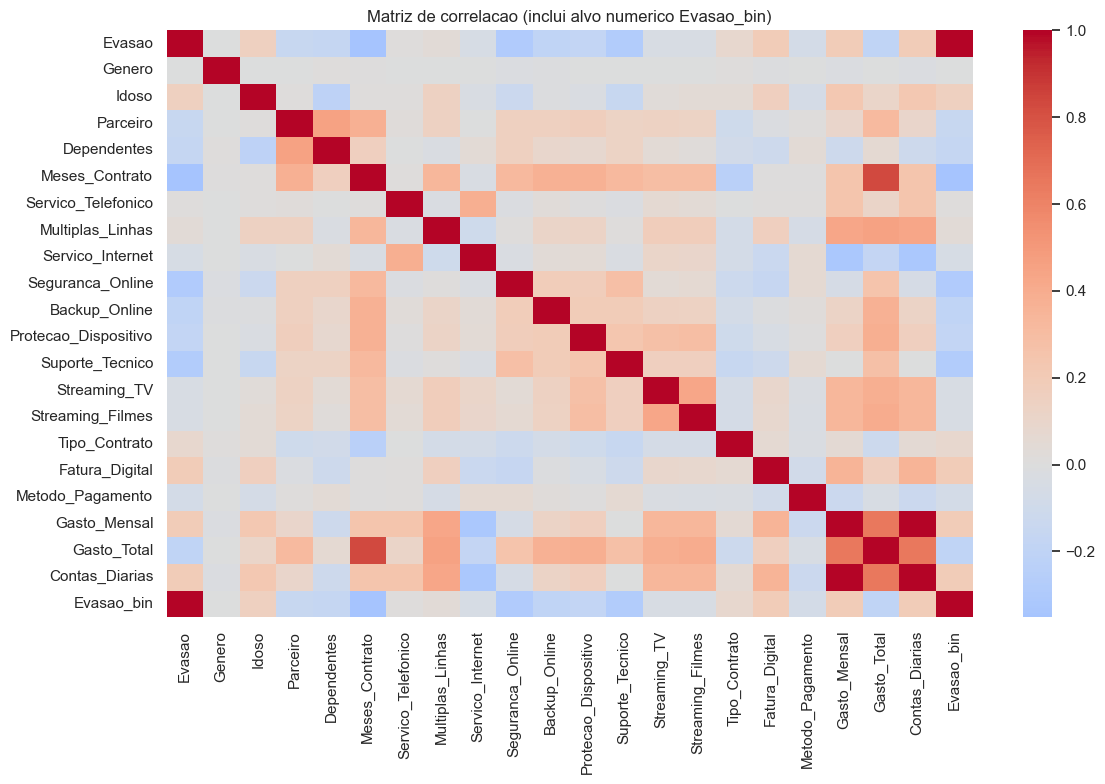

,Correlacao com Evasao_bin
Evasao,1.000000
Meses_Contrato,-0.352229
Seguranca_Online,-0.289309
Suporte_Tecnico,-0.282492
Gasto_Total,-0.198324
Backup_Online,-0.195525
Gasto_Mensal,0.193356
Contas_Diarias,0.193356
Fatura_Digital,0.191825
Protecao_Dispositivo,-0.178134


In [5]:
corr_df = df_model.copy()
for col in corr_df.select_dtypes(include='object').columns:
    corr_df[col] = corr_df[col].astype('category').cat.codes

corr = corr_df.corr(numeric_only=True)
top_corr = corr['Evasao_bin'].drop('Evasao_bin').sort_values(key=np.abs, ascending=False).head(12)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matriz de correlacao (inclui alvo numerico Evasao_bin)')
plt.tight_layout()
plt.show()

display(top_corr.to_frame('Correlacao com Evasao_bin'))

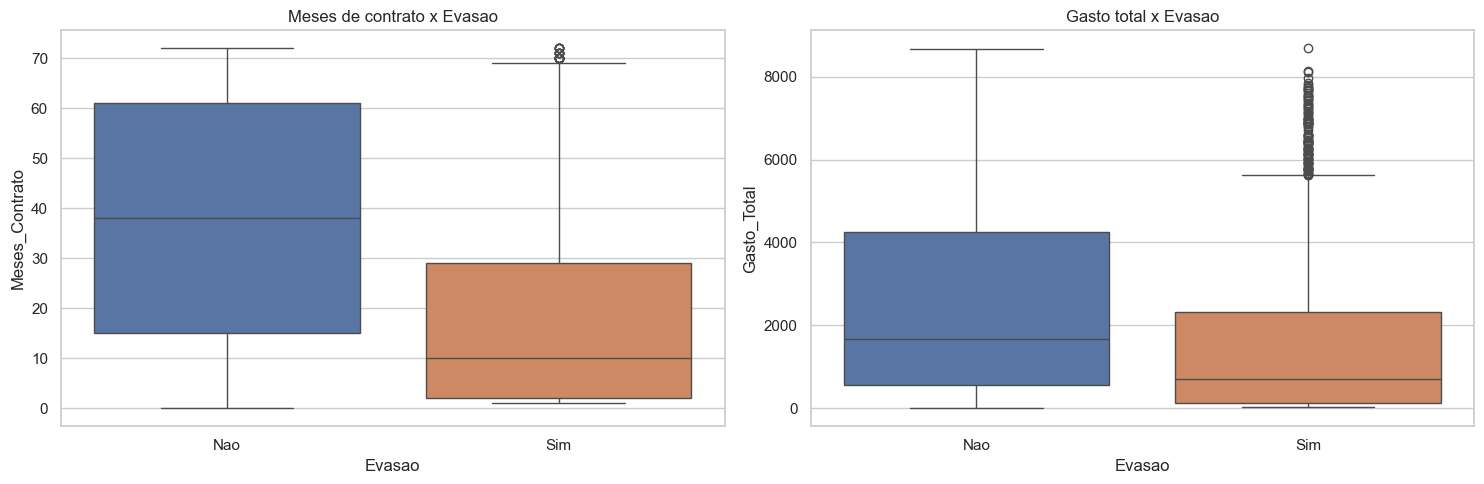

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df_model, x='Evasao', y='Meses_Contrato', hue='Evasao', legend=False, ax=ax[0])
ax[0].set_title('Meses de contrato x Evasao')

sns.boxplot(data=df_model, x='Evasao', y='Gasto_Total', hue='Evasao', legend=False, ax=ax[1])
ax[1].set_title('Gasto total x Evasao')

plt.tight_layout()
plt.show()

## Split de treino e teste

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)

Treino: (5634, 20) | Teste: (1409, 20)


## Modelos
### Modelo 1 - Regressao Logistica (com padronizacao)
Modelo linear, interpretavel e sensivel a escala.

### Modelo 2 - Random Forest (sem padronizacao)
Modelo de arvores, robusto a nao linearidades e nao sensivel a escala.

In [8]:
preprocess_lr = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_features),
    ]
)

preprocess_rf = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_features),
    ]
)

modelo_lr = Pipeline([
    ('prep', preprocess_lr),
    ('clf', LogisticRegression(max_iter=2000, random_state=42))
])

modelo_rf = Pipeline([
    ('prep', preprocess_rf),
    ('clf', RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced'))
])

modelo_lr.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

--- Regressao Logistica ---
              precision    recall  f1-score   support

  Permaneceu       0.84      0.89      0.86      1035
     Evadido       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



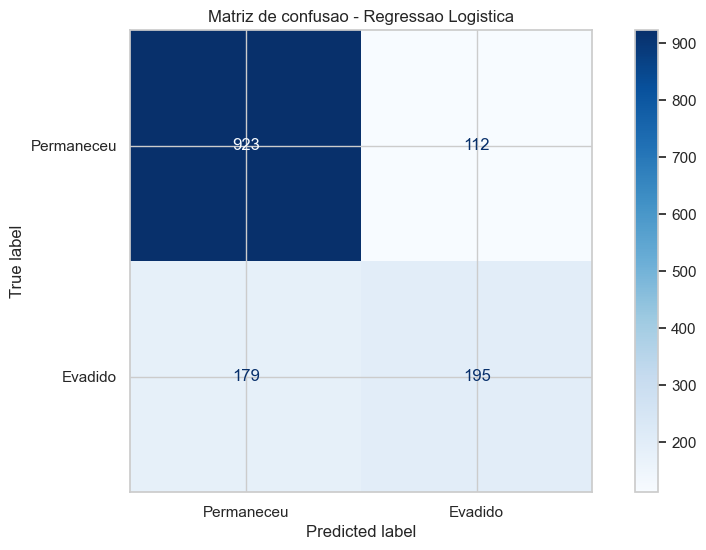

--- Random Forest ---
              precision    recall  f1-score   support

  Permaneceu       0.83      0.90      0.86      1035
     Evadido       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



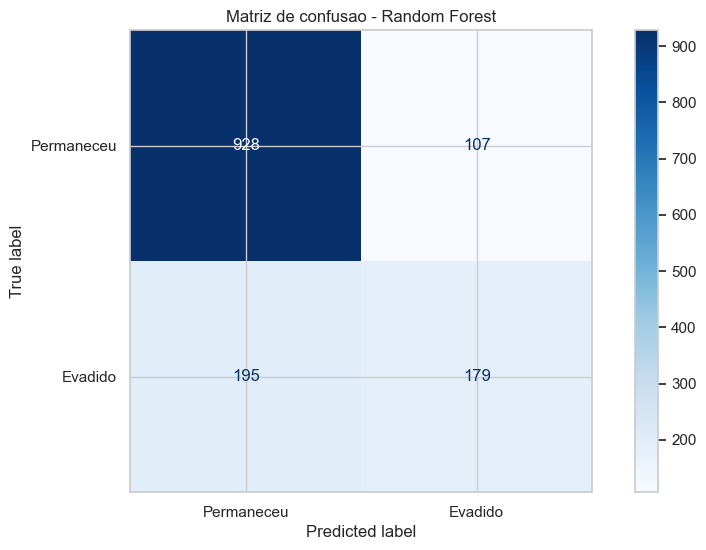

AttributeError: The '.style' accessor requires jinja2

In [ ]:
def avaliar_modelo(nome, modelo, X_train, y_train, X_test, y_test):
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    resultados = {
        'Modelo': nome,
        'Acuracia_treino': accuracy_score(y_train, y_pred_train),
        'Acuracia_teste': accuracy_score(y_test, y_pred_test),
        'Precisao': precision_score(y_test, y_pred_test),
        'Recall': recall_score(y_test, y_pred_test),
        'F1-score': f1_score(y_test, y_pred_test),
    }

    cm = confusion_matrix(y_test, y_pred_test)

    print(f'--- {nome} ---')
    print(classification_report(y_test, y_pred_test, target_names=['Permaneceu', 'Evadido']))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Permaneceu', 'Evadido'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de confusao - {nome}')
    plt.show()

    return resultados

res_lr = avaliar_modelo('Regressao Logistica', modelo_lr, X_train, y_train, X_test, y_test)
res_rf = avaliar_modelo('Random Forest', modelo_rf, X_train, y_train, X_test, y_test)

df_resultados = pd.DataFrame([res_lr, res_rf]).set_index('Modelo')
display(df_resultados.round(4))

In [10]:
gap = df_resultados['Acuracia_treino'] - df_resultados['Acuracia_teste']
diagnostico = pd.DataFrame({
    'Gap treino-teste': gap.round(4),
    'Leitura': [
        'Maior risco de overfitting' if v > 0.05 else 'Generalizacao adequada'
        for v in gap
    ]
})
display(diagnostico)

,Gap treino-teste,Leitura
Modelo,,
Regressao Logistica,0.0168,Generalizacao adequada
Random Forest,0.2120,Maior risco de overfitting


## Interpretacao das variaveis mais relevantes

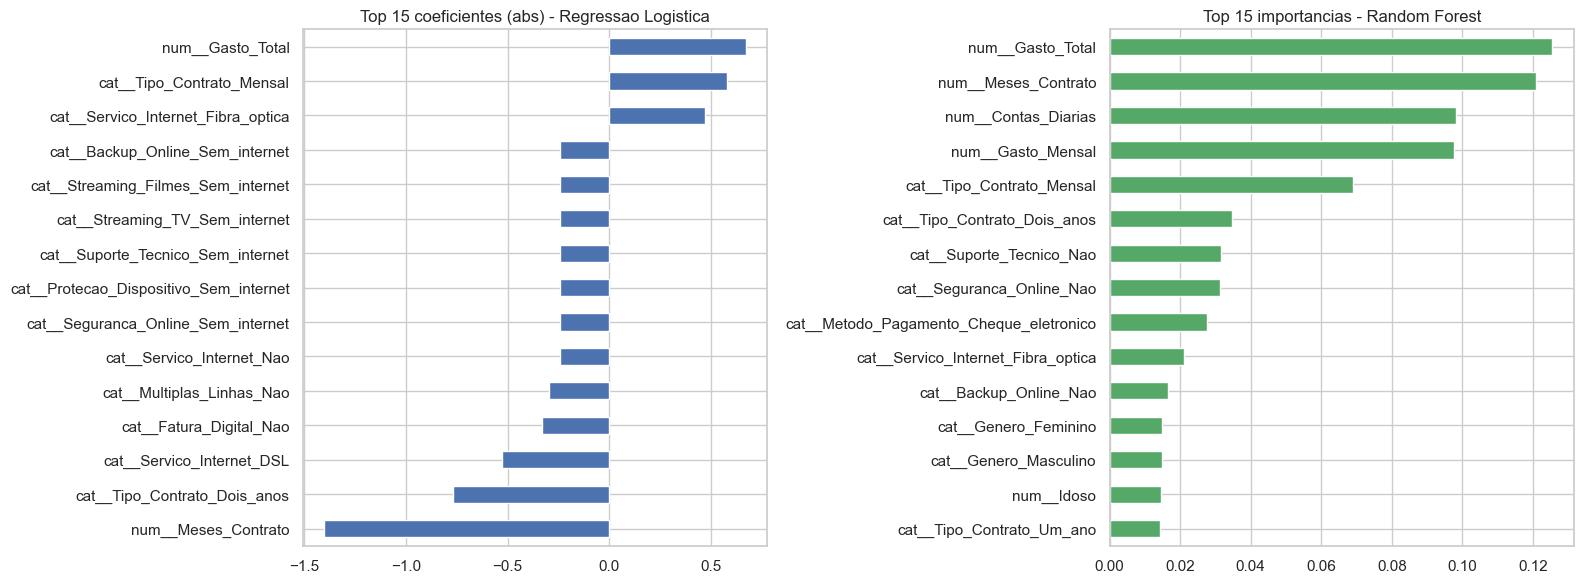

,coef_lr_abs_top
num__Meses_Contrato,-1.403965
cat__Tipo_Contrato_Dois_anos,-0.768383
num__Gasto_Total,0.673653
cat__Tipo_Contrato_Mensal,0.581036
cat__Servico_Internet_DSL,-0.526884
cat__Servico_Internet_Fibra_optica,0.473153
cat__Fatura_Digital_Nao,-0.330161
cat__Multiplas_Linhas_Nao,-0.294640
cat__Protecao_Dispositivo_Sem_internet,-0.241568
cat__Seguranca_Online_Sem_internet,-0.241568


,rf_importance_top
num__Gasto_Total,0.125349
num__Meses_Contrato,0.120766
num__Contas_Diarias,0.098128
num__Gasto_Mensal,0.097617
cat__Tipo_Contrato_Mensal,0.069035
cat__Tipo_Contrato_Dois_anos,0.034725
cat__Suporte_Tecnico_Nao,0.031555
cat__Seguranca_Online_Nao,0.031192
cat__Metodo_Pagamento_Cheque_eletronico,0.027631
cat__Servico_Internet_Fibra_optica,0.021066


In [11]:
feature_names_lr = modelo_lr.named_steps['prep'].get_feature_names_out()
coef_lr = modelo_lr.named_steps['clf'].coef_[0]
imp_lr = pd.Series(coef_lr, index=feature_names_lr).sort_values(key=np.abs, ascending=False).head(15)

feature_names_rf = modelo_rf.named_steps['prep'].get_feature_names_out()
imp_rf_vals = modelo_rf.named_steps['clf'].feature_importances_
imp_rf = pd.Series(imp_rf_vals, index=feature_names_rf).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
imp_lr.sort_values().plot(kind='barh', ax=ax[0], color='#4c72b0')
ax[0].set_title('Top 15 coeficientes (abs) - Regressao Logistica')

imp_rf.sort_values().plot(kind='barh', ax=ax[1], color='#55a868')
ax[1].set_title('Top 15 importancias - Random Forest')

plt.tight_layout()
plt.show()

display(imp_lr.to_frame('coef_lr_abs_top'))
display(imp_rf.to_frame('rf_importance_top'))

In [12]:
melhor_modelo = df_resultados['F1-score'].idxmax()
melhor_f1 = df_resultados.loc[melhor_modelo, 'F1-score']
melhor_recall = df_resultados.loc[melhor_modelo, 'Recall']

top_lr = imp_lr.head(5).index.tolist()
top_rf = imp_rf.head(5).index.tolist()

resumo_md = f"""
## Relatorio executivo
- Melhor modelo pelo F1-score: **{melhor_modelo}** (F1 = **{melhor_f1:.4f}**, Recall = **{melhor_recall:.4f}**).
- A comparacao entre acuracia de treino e teste indica o nivel de generalizacao de cada abordagem.
- Fatores relevantes observados em ambos os modelos concentram-se em tempo de contrato, padrao de gasto e tipo de servico/contrato.

### Top sinais no modelo linear (Regressao Logistica)
{chr(10).join([f'- `{item}`' for item in top_lr])}

### Top sinais no modelo de arvore (Random Forest)
{chr(10).join([f'- `{item}`' for item in top_rf])}

## Recomendacoes de retencao
1. Criar acoes preventivas para clientes em contrato mensal, principalmente nos primeiros meses.
2. Monitorar clientes com aumento de gasto mensal e baixo tempo de permanencia.
3. Priorizar ofertas de fidelizacao para segmentos com maior propensao de churn.
4. Evoluir a solucao com tuning de hiperparametros e avaliacao com validacao cruzada.
"""

display(Markdown(resumo_md))


## Relatorio executivo
- Melhor modelo pelo F1-score: **Regressao Logistica** (F1 = **0.5727**, Recall = **0.5214**).
- A comparacao entre acuracia de treino e teste indica o nivel de generalizacao de cada abordagem.
- Fatores relevantes observados em ambos os modelos concentram-se em tempo de contrato, padrao de gasto e tipo de servico/contrato.

### Top sinais no modelo linear (Regressao Logistica)
- `num__Meses_Contrato`
- `cat__Tipo_Contrato_Dois_anos`
- `num__Gasto_Total`
- `cat__Tipo_Contrato_Mensal`
- `cat__Servico_Internet_DSL`

### Top sinais no modelo de arvore (Random Forest)
- `num__Gasto_Total`
- `num__Meses_Contrato`
- `num__Contas_Diarias`
- `num__Gasto_Mensal`
- `cat__Tipo_Contrato_Mensal`

## Recomendacoes de retencao
1. Criar acoes preventivas para clientes em contrato mensal, principalmente nos primeiros meses.
2. Monitorar clientes com aumento de gasto mensal e baixo tempo de permanencia.
3. Priorizar ofertas de fidelizacao para segmentos com maior propensao de churn.
4. Evoluir a solucao com tuning de hiperparametros e avaliacao com validacao cruzada.


## Conclusao estrategica

1. O experimento comparou modelos lineares e baseados em arvores para prever churn.
2. As metricas de precisao, recall e F1-score devem ser priorizadas junto com acuracia devido ao desbalanceamento.
3. Variaveis relacionadas a tipo de contrato, tempo de permanencia e padrao de gastos aparecem como fatores centrais de risco.
4. Para negocio, a recomendacao e focar campanhas preventivas em clientes com sinais de risco alto logo nos primeiros meses.
5. Proximos passos: calibracao de hiperparametros, validacao cruzada e teste com tecnicas de balanceamento (ex.: SMOTE).